In [1]:
%load_ext autoreload
%autoreload 

In [2]:
# import standard python libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# Import python package for working with cooler files and tools for analysis
import cooler
import cooltools.lib.plotting
from cooltools import insulation

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.4'):
    raise AssertionError("tutorials rely on cooltools version 0.5.4 or higher,"+
                         "please check your cooltools version and update to the latest")

In [4]:
import cooler
#from cooltools.insulation import insulation
resolution = 5000
# Load Coolers with the specified resolution dynamically using f-strings
clr_1 = cooler.Cooler(f"/usr/users/papantonis1/aman/microc_data/nadine_macro/RBP1-MNase-R1-filtered.mcool::resolutions/{resolution}")
clr_2 = cooler.Cooler(f"/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/{resolution}")
# Define window sizes as multiples of the resolution
windows = [3*resolution, 5*resolution, 10*resolution, 25*resolution]
# Run insulation analysis
insulation_table_1 = insulation(clr_1, windows, verbose=True)
insulation_table_2 = insulation(clr_2, windows, verbose=True)

INFO:root:fallback to serial implementation.
INFO:root:Processing region chr1
INFO:root:Processing region chr2
INFO:root:Processing region chr3
INFO:root:Processing region chr4
INFO:root:Processing region chr5
INFO:root:Processing region chr6
INFO:root:Processing region chr7
INFO:root:Processing region chr8
INFO:root:Processing region chr9
INFO:root:Processing region chr10
INFO:root:Processing region chr11
INFO:root:Processing region chr12
INFO:root:Processing region chr13
INFO:root:Processing region chr14
INFO:root:Processing region chr15
INFO:root:Processing region chr16
INFO:root:Processing region chr17
INFO:root:Processing region chr18
INFO:root:Processing region chr19
INFO:root:Processing region chr20
INFO:root:Processing region chr21
INFO:root:Processing region chr22
INFO:root:Processing region chrX
INFO:root:Processing region chrY
INFO:root:Processing region chrM
INFO:root:fallback to serial implementation.
INFO:root:Processing region chr1
INFO:root:Processing region chr2
INFO:r

In [5]:
first_window_summary =insulation_table_1.columns[[ str(windows[-1]) in i for i in insulation_table_1.columns]]

insulation_table_1[['chrom','start','end','region','is_bad_bin']+list(first_window_summary)].iloc[1000:1005]

,chrom,start,end,region,is_bad_bin,log2_insulation_score_125000,n_valid_pixels_125000,boundary_strength_125000,is_boundary_125000
1000,chr1,5000000,5005000,chr1,False,-0.067126,622.0,0.055201,False
1001,chr1,5005000,5010000,chr1,False,-0.053283,622.0,NaN,False
1002,chr1,5010000,5015000,chr1,False,-0.040111,622.0,NaN,False
1003,chr1,5015000,5020000,chr1,False,-0.022033,622.0,NaN,False
1004,chr1,5020000,5025000,chr1,False,-0.032163,622.0,0.010130,False


In [6]:
# Functions to help with plotting
def pcolormesh_45deg(ax, matrix_c, start=0, resolution=1, *args, **kwargs):
    start_pos_vector = [start+resolution*i for i in range(len(matrix_c)+1)]
    import itertools
    n = matrix_c.shape[0]
    t = np.array([[1, 0.5], [-1, 0.5]])
    matrix_a = np.dot(np.array([(i[1], i[0])
                                for i in itertools.product(start_pos_vector[::-1],
                                                           start_pos_vector)]), t)
    x = matrix_a[:, 1].reshape(n + 1, n + 1)
    y = matrix_a[:, 0].reshape(n + 1, n + 1)
    im = ax.pcolormesh(x, y, np.flipud(matrix_c), *args, **kwargs)
    im.set_rasterized(True)
    return im

from matplotlib.ticker import EngFormatter
bp_formatter = EngFormatter('b')
def format_ticks(ax, x=True, y=True, rotate=True):
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.tick_bottom()
    if rotate:
        ax.tick_params(axis='x',rotation=45)

(10500000.0, 11850000.0)

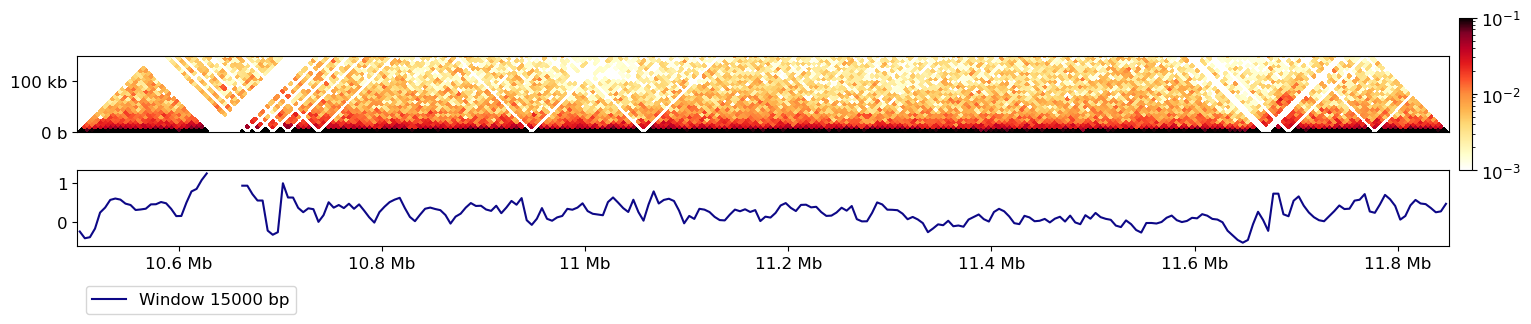

In [7]:
#chr 1
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import bioframe
plt.rcParams['font.size'] = 12

start = 10_500_000
end = start+ 90*windows[0]
region = ('chr1', start, end)
norm = LogNorm(vmax=0.1, vmin=0.001)
data = clr_1.matrix(balance=True).fetch(region)
f, ax = plt.subplots(figsize=(18, 6))
im = pcolormesh_45deg(ax, data, start=region[1], resolution=resolution, norm=norm, cmap='fall')
ax.set_aspect(0.5)
ax.set_ylim(0, 10*windows[0])
format_ticks(ax, rotate=False)
ax.xaxis.set_visible(False)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="1%", pad=0.1, aspect=6)
plt.colorbar(im, cax=cax)

insul_region = bioframe.select(insulation_table_1, region)

ins_ax = divider.append_axes("bottom", size="50%", pad=0., sharex=ax)
ins_ax.set_prop_cycle(plt.cycler("color", plt.cm.plasma(np.linspace(0,1,5))))
ins_ax.plot(insul_region[['start', 'end']].mean(axis=1),
            insul_region['log2_insulation_score_'+str(windows[0])],
            label=f'Window {windows[0]} bp')

ins_ax.legend(bbox_to_anchor=(0., -1), loc='lower left', ncol=4);

format_ticks(ins_ax, y=False, rotate=False)
ax.set_xlim(region[1], region[2])

(10500000.0, 11850000.0)

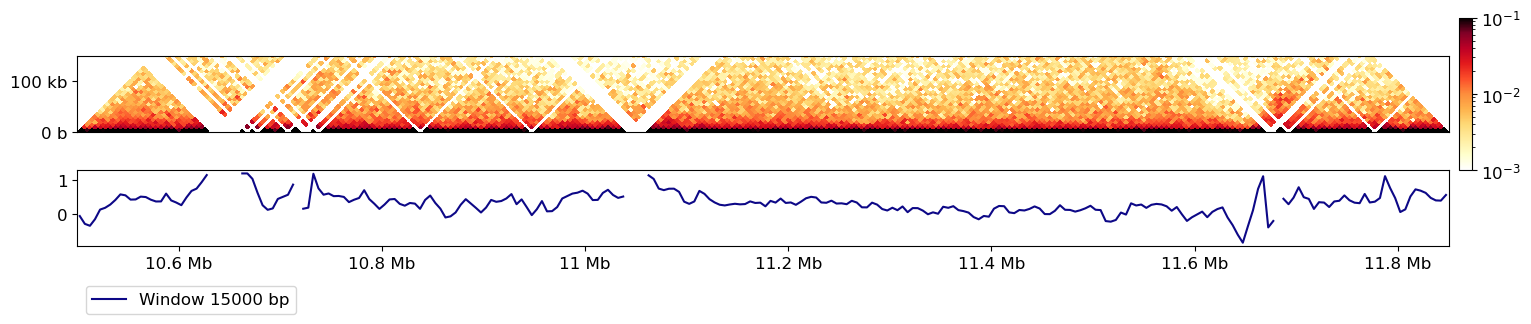

In [8]:
#chr 1
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import bioframe
plt.rcParams['font.size'] = 12

start = 10_500_000
end = start+ 90*windows[0]
region = ('chr1', start, end)
norm = LogNorm(vmax=0.1, vmin=0.001)
data = clr_2.matrix(balance=True).fetch(region)
f, ax = plt.subplots(figsize=(18, 6))
im = pcolormesh_45deg(ax, data, start=region[1], resolution=resolution, norm=norm, cmap='fall')
ax.set_aspect(0.5)
ax.set_ylim(0, 10*windows[0])
format_ticks(ax, rotate=False)
ax.xaxis.set_visible(False)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="1%", pad=0.1, aspect=6)
plt.colorbar(im, cax=cax)

insul_region = bioframe.select(insulation_table_2, region)

ins_ax = divider.append_axes("bottom", size="50%", pad=0., sharex=ax)
ins_ax.set_prop_cycle(plt.cycler("color", plt.cm.plasma(np.linspace(0,1,5))))
ins_ax.plot(insul_region[['start', 'end']].mean(axis=1),
            insul_region['log2_insulation_score_'+str(windows[0])],
            label=f'Window {windows[0]} bp')

ins_ax.legend(bbox_to_anchor=(0., -1), loc='lower left', ncol=4);

format_ticks(ins_ax, y=False, rotate=False)
ax.set_xlim(region[1], region[2])

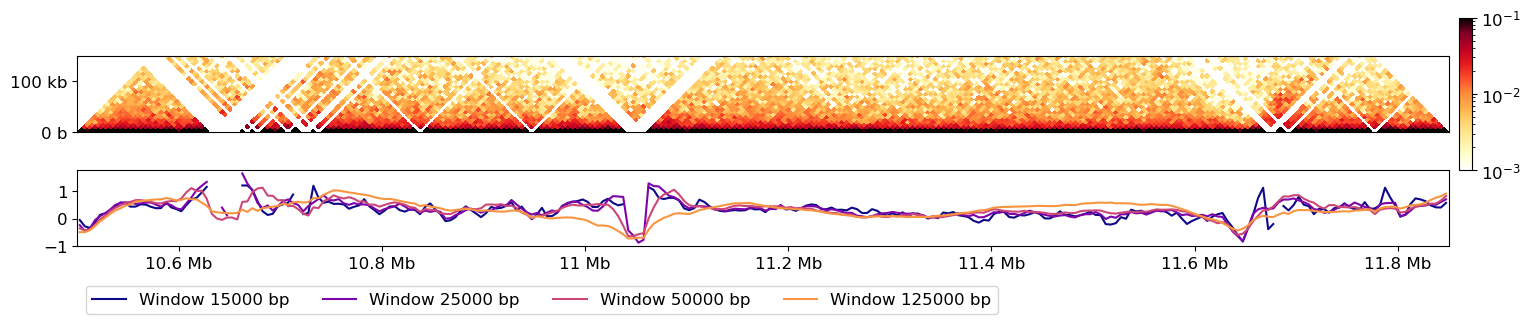

In [9]:
# chr1
for res in windows[1:]:
    ins_ax.plot(insul_region[['start', 'end']].mean(axis=1), insul_region[f'log2_insulation_score_{res}'], label=f'Window {res} bp')
ins_ax.legend(bbox_to_anchor=(0., -1), loc='lower left', ncol=4);
f

In [10]:
#why many windows? check again

In [11]:
# boundary calling

(10500000.0, 11850000.0)

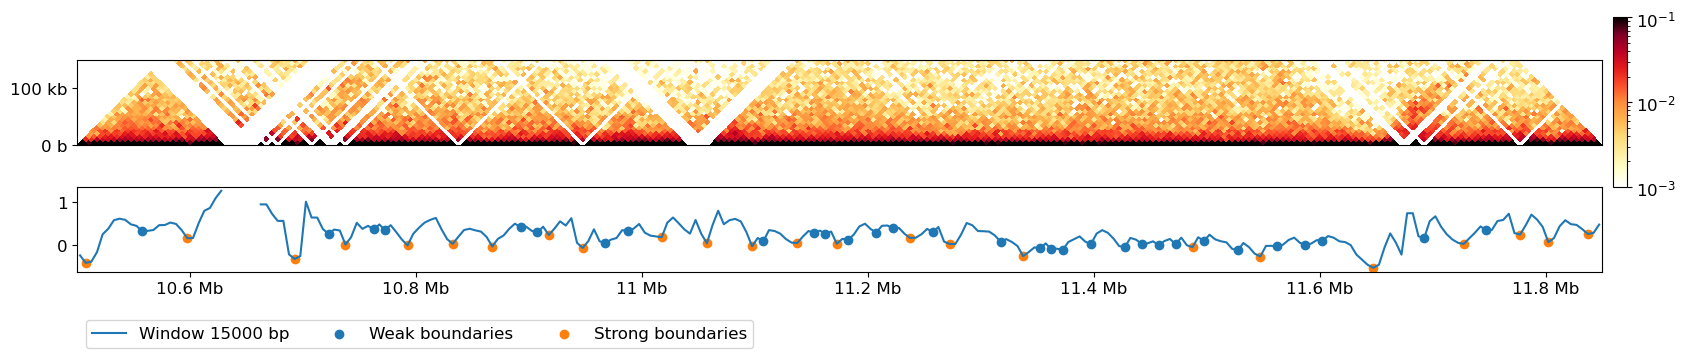

In [12]:
f, ax = plt.subplots(figsize=(20, 10))
im = pcolormesh_45deg(ax, data, start=region[1], resolution=resolution, norm=norm, cmap='fall')
ax.set_aspect(0.5)
ax.set_ylim(0, 10*windows[0])
format_ticks(ax, rotate=False)
ax.xaxis.set_visible(False)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="1%", pad=0.1, aspect=6)
plt.colorbar(im, cax=cax)

insul_region = bioframe.select(insulation_table_1, region)

ins_ax = divider.append_axes("bottom", size="50%", pad=0., sharex=ax)

ins_ax.plot(insul_region[['start', 'end']].mean(axis=1),
            insul_region[f'log2_insulation_score_{windows[0]}'], label=f'Window {windows[0]} bp')

boundaries = insul_region[~np.isnan(insul_region[f'boundary_strength_{windows[0]}'])]
weak_boundaries = boundaries[~boundaries[f'is_boundary_{windows[0]}']]
strong_boundaries = boundaries[boundaries[f'is_boundary_{windows[0]}']]
ins_ax.scatter(weak_boundaries[['start', 'end']].mean(axis=1),
            weak_boundaries[f'log2_insulation_score_{windows[0]}'], label='Weak boundaries')
ins_ax.scatter(strong_boundaries[['start', 'end']].mean(axis=1),
            strong_boundaries[f'log2_insulation_score_{windows[0]}'], label='Strong boundaries')

ins_ax.legend(bbox_to_anchor=(0., -1), loc='lower left', ncol=4);

format_ticks(ins_ax, y=False, rotate=False)
ax.set_xlim(region[1], region[2])

(10500000.0, 11850000.0)

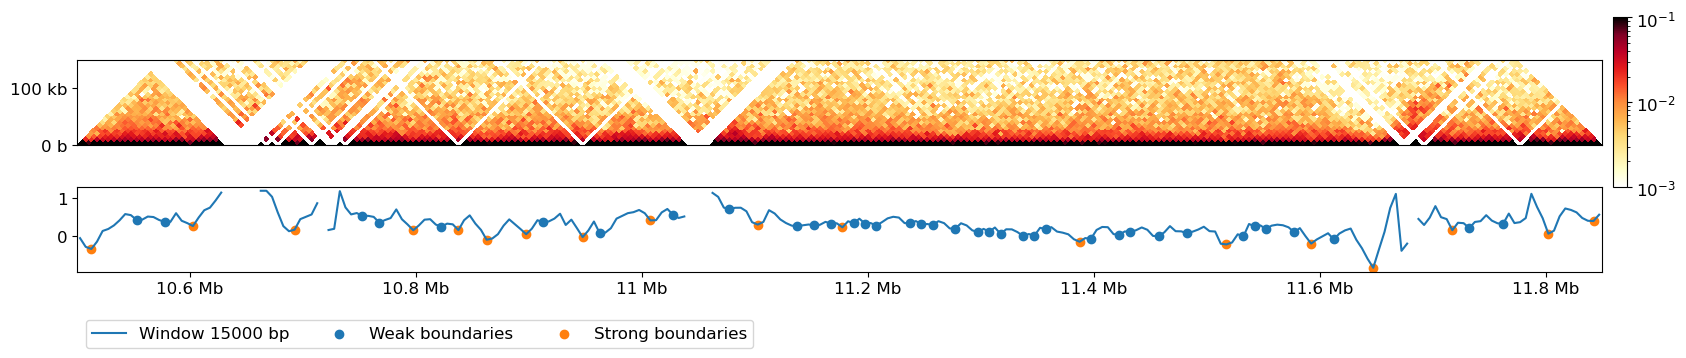

In [13]:
f, ax = plt.subplots(figsize=(20, 10))
im = pcolormesh_45deg(ax, data, start=region[1], resolution=resolution, norm=norm, cmap='fall')
ax.set_aspect(0.5)
ax.set_ylim(0, 10*windows[0])
format_ticks(ax, rotate=False)
ax.xaxis.set_visible(False)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="1%", pad=0.1, aspect=6)
plt.colorbar(im, cax=cax)

insul_region = bioframe.select(insulation_table_2, region)

ins_ax = divider.append_axes("bottom", size="50%", pad=0., sharex=ax)

ins_ax.plot(insul_region[['start', 'end']].mean(axis=1),
            insul_region[f'log2_insulation_score_{windows[0]}'], label=f'Window {windows[0]} bp')

boundaries = insul_region[~np.isnan(insul_region[f'boundary_strength_{windows[0]}'])]
weak_boundaries = boundaries[~boundaries[f'is_boundary_{windows[0]}']]
strong_boundaries = boundaries[boundaries[f'is_boundary_{windows[0]}']]
ins_ax.scatter(weak_boundaries[['start', 'end']].mean(axis=1),
            weak_boundaries[f'log2_insulation_score_{windows[0]}'], label='Weak boundaries')
ins_ax.scatter(strong_boundaries[['start', 'end']].mean(axis=1),
            strong_boundaries[f'log2_insulation_score_{windows[0]}'], label='Strong boundaries')

ins_ax.legend(bbox_to_anchor=(0., -1), loc='lower left', ncol=4);

format_ticks(ins_ax, y=False, rotate=False)
ax.set_xlim(region[1], region[2])

In [14]:
# boundary strength

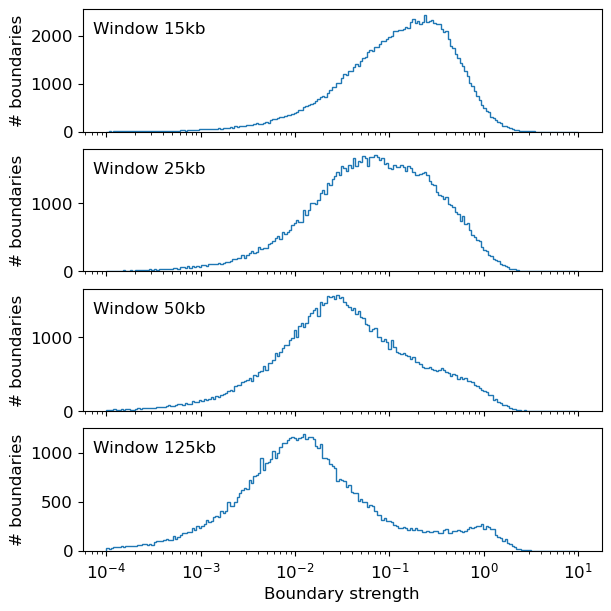

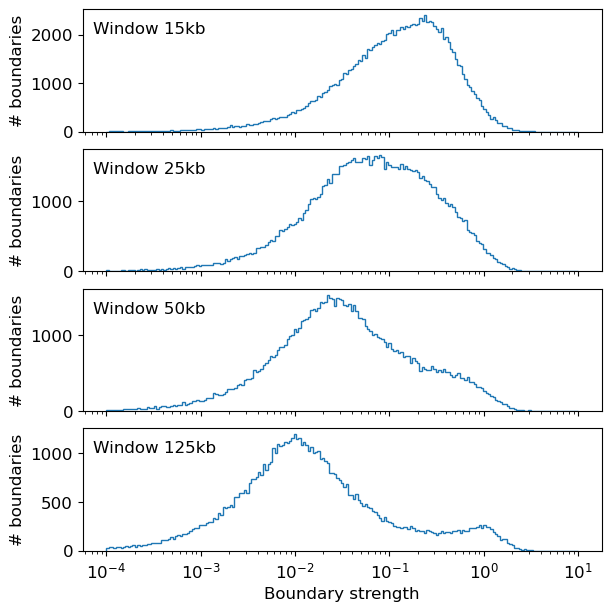

In [15]:
histkwargs = dict(
    bins=10**np.linspace(-4,1,200),
    histtype='step',
    lw=2,
)

f, axs = plt.subplots(len(windows),1, sharex=True, figsize=(6,6), constrained_layout=True)
for i, (w, ax) in enumerate(zip(windows, axs)):
    ax.hist(
        insulation_table_1[f'boundary_strength_{w}'],
        **histkwargs
    )
    ax.text(0.02, 0.9,
             f'Window {w//1000}kb',
             ha='left',
             va='top',
             transform=ax.transAxes)

    ax.set(
        xscale='log',
        ylabel='# boundaries'
    )

axs[-1].set(xlabel='Boundary strength');

###

histkwargs = dict(
    bins=10**np.linspace(-4,1,200),
    histtype='step',
    lw=2,
)

f, axs = plt.subplots(len(windows),1, sharex=True, figsize=(6,6), constrained_layout=True)
for i, (w, ax) in enumerate(zip(windows, axs)):
    ax.hist(
        insulation_table_2[f'boundary_strength_{w}'],
        **histkwargs
    )
    ax.text(0.02, 0.9,
             f'Window {w//1000}kb',
             ha='left',
             va='top',
             transform=ax.transAxes)

    ax.set(
        xscale='log',
        ylabel='# boundaries'
    )

axs[-1].set(xlabel='Boundary strength');


[Text(0.5, 0, 'Boundary strength')]

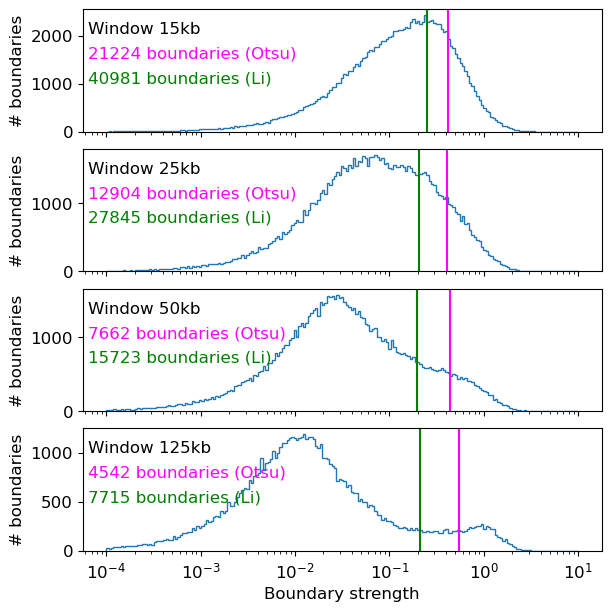

In [16]:
from skimage.filters import threshold_li, threshold_otsu

f, axs = plt.subplots(len(windows), 1, sharex=True, figsize=(6,6), constrained_layout=True)
thresholds_li_1 = {}
thresholds_otsu_1 = {}
for i, (w, ax) in enumerate(zip(windows, axs)):
    ax.hist(
        insulation_table_1[f'boundary_strength_{w}'],
        **histkwargs
    )
    thresholds_li_1[w] = threshold_li(insulation_table_1[f'boundary_strength_{w}'].dropna().values)
    thresholds_otsu_1[w] = threshold_otsu(insulation_table_1[f'boundary_strength_{w}'].dropna().values)
    n_boundaries_li = (insulation_table_1[f'boundary_strength_{w}'].dropna()>=thresholds_li_1[w]).sum()
    n_boundaries_otsu = (insulation_table_1[f'boundary_strength_{w}'].dropna()>=thresholds_otsu_1[w]).sum()
    ax.axvline(thresholds_li_1[w], c='green')
    ax.axvline(thresholds_otsu_1[w], c='magenta')
    ax.text(0.01, 0.9,
             f'Window {w//1000}kb',
             ha='left',
             va='top',
             transform=ax.transAxes)
    ax.text(0.01, 0.7,
            f'{n_boundaries_otsu} boundaries (Otsu)',
            c='magenta',
            ha='left',
            va='top',
            transform=ax.transAxes)
    ax.text(0.01, 0.5,
            f'{n_boundaries_li} boundaries (Li)',
            c='green',
            ha='left',
            va='top',
            transform=ax.transAxes)

    ax.set(
        xscale='log',
        ylabel='# boundaries'
    )

axs[-1].set(xlabel='Boundary strength')

[Text(0.5, 0, 'Boundary strength')]

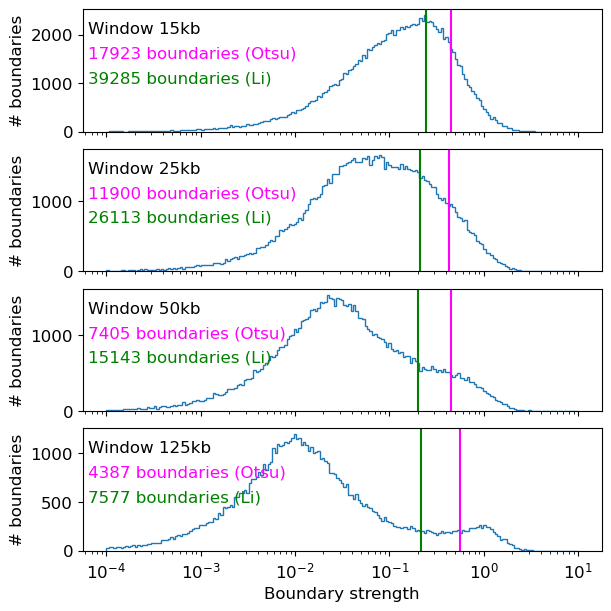

In [17]:
from skimage.filters import threshold_li, threshold_otsu

f, axs = plt.subplots(len(windows), 1, sharex=True, figsize=(6,6), constrained_layout=True)
thresholds_li_2 = {}
thresholds_otsu_2 = {}
for i, (w, ax) in enumerate(zip(windows, axs)):
    ax.hist(
        insulation_table_2[f'boundary_strength_{w}'],
        **histkwargs
    )
    thresholds_li_2[w] = threshold_li(insulation_table_2[f'boundary_strength_{w}'].dropna().values)
    thresholds_otsu_2[w] = threshold_otsu(insulation_table_2[f'boundary_strength_{w}'].dropna().values)
    n_boundaries_li = (insulation_table_2[f'boundary_strength_{w}'].dropna()>=thresholds_li_2[w]).sum()
    n_boundaries_otsu = (insulation_table_2[f'boundary_strength_{w}'].dropna()>=thresholds_otsu_2[w]).sum()
    ax.axvline(thresholds_li_2[w], c='green')
    ax.axvline(thresholds_otsu_2[w], c='magenta')
    ax.text(0.01, 0.9,
             f'Window {w//1000}kb',
             ha='left',
             va='top',
             transform=ax.transAxes)
    ax.text(0.01, 0.7,
            f'{n_boundaries_otsu} boundaries (Otsu)',
            c='magenta',
            ha='left',
            va='top',
            transform=ax.transAxes)
    ax.text(0.01, 0.5,
            f'{n_boundaries_li} boundaries (Li)',
            c='green',
            ha='left',
            va='top',
            transform=ax.transAxes)

    ax.set(
        xscale='log',
        ylabel='# boundaries'
    )

axs[-1].set(xlabel='Boundary strength')

In [18]:
#CTCF enrichment at boundaries

In [19]:
# Download test data. The file size is 592 Mb, so the download might take a while:
ctcf_fc_file = cooltools.download_data("HFF_CTCF_fc", cache=True, data_dir="/usr/users/papantonis1/aman/microc_project/refgen")

In [20]:
import bbi

In [21]:
is_boundary_1 = np.any([
        ~insulation_table_1[f'boundary_strength_{w}'].isnull()
        for w in windows],
    axis=0)
boundaries_1 = insulation_table_1[is_boundary_1]

###

is_boundary_2 = np.any([
        ~insulation_table_2[f'boundary_strength_{w}'].isnull()
        for w in windows],
    axis=0)
boundaries_2 = insulation_table_2[is_boundary_2]

In [22]:
boundaries_1.head()

,chrom,start,end,region,is_bad_bin,log2_insulation_score_15000,n_valid_pixels_15000,log2_insulation_score_25000,n_valid_pixels_25000,log2_insulation_score_50000,...,log2_insulation_score_125000,n_valid_pixels_125000,boundary_strength_15000,boundary_strength_125000,boundary_strength_50000,boundary_strength_25000,is_boundary_15000,is_boundary_25000,is_boundary_50000,is_boundary_125000
361,chr1,1805000,1810000,chr1,False,1.088096,6.0,1.383007,22.0,1.991580,...,3.009447,82.0,0.396659,NaN,NaN,0.066370,True,False,False,False
363,chr1,1815000,1820000,chr1,False,1.287084,6.0,1.385585,22.0,1.922440,...,2.984936,102.0,NaN,NaN,NaN,0.047368,False,False,False,False
365,chr1,1825000,1830000,chr1,False,1.199921,6.0,1.334292,22.0,1.771849,...,2.926144,114.0,NaN,NaN,NaN,0.081866,False,False,False,False
366,chr1,1830000,1835000,chr1,False,1.119380,6.0,1.416158,22.0,1.715573,...,2.798619,127.0,0.230952,NaN,NaN,NaN,False,False,False,False
368,chr1,1840000,1845000,chr1,False,1.369879,6.0,1.362636,22.0,1.672675,...,2.763504,129.0,NaN,NaN,0.016726,NaN,False,False,False,False


In [23]:
boundaries_2.head()

,chrom,start,end,region,is_bad_bin,log2_insulation_score_15000,n_valid_pixels_15000,log2_insulation_score_25000,n_valid_pixels_25000,log2_insulation_score_50000,...,log2_insulation_score_125000,n_valid_pixels_125000,boundary_strength_15000,boundary_strength_125000,boundary_strength_50000,boundary_strength_25000,is_boundary_15000,is_boundary_25000,is_boundary_50000,is_boundary_125000
364,chr1,1820000,1825000,chr1,False,1.341736,6.0,1.574417,22.0,1.981818,...,3.090806,88.0,0.169714,NaN,NaN,NaN,False,False,False,False
365,chr1,1825000,1830000,chr1,False,1.348316,6.0,1.497850,22.0,1.903092,...,3.049646,93.0,NaN,NaN,NaN,0.045447,False,False,False,False
368,chr1,1840000,1845000,chr1,False,1.511450,6.0,1.523614,22.0,1.800124,...,2.756831,118.0,NaN,NaN,0.087606,NaN,False,False,False,False
369,chr1,1845000,1850000,chr1,False,1.415230,6.0,1.475594,22.0,1.812463,...,2.715799,117.0,NaN,NaN,NaN,0.004931,False,False,False,False
371,chr1,1855000,1860000,chr1,False,1.326143,6.0,1.383689,22.0,1.918991,...,2.645545,109.0,0.671049,NaN,NaN,0.339284,True,True,False,False


In [24]:
flank = 1000
ctcf_chip_signal_1 = bbi.stackup(
    "/usr/users/papantonis1/aman/microc_data/nadine_macro/CPI_CTCF.bw_RPGC.bw",
    boundaries_1.chrom,
    boundaries_1.start - flank,
    boundaries_1.end + flank,
    bins=1
).flatten()

In [25]:
flank = 1000  # Length of flank to one side from the boundary, in basepairs
ctcf_chip_signal_2 = bbi.stackup(
    "/usr/users/papantonis1/aman/microc_data/nadine_macro/C_CTCF.bw_RPGC.bw",
    boundaries_2.chrom,
    boundaries_2.start - flank,
    boundaries_2.end + flank,
    bins=1
).flatten()

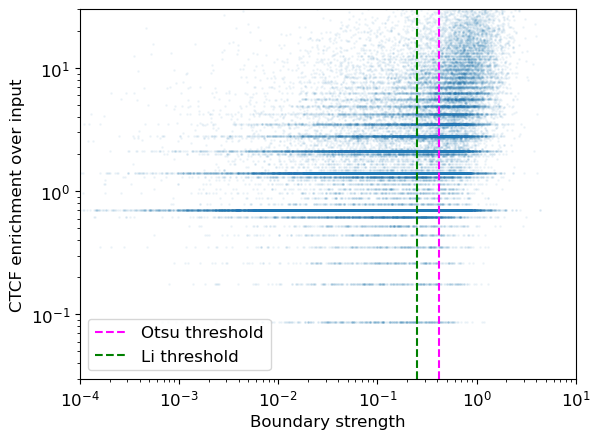

In [26]:
w=windows[0]
f, ax = plt.subplots()
ax.loglog(
    boundaries_1[f'boundary_strength_{w}'],
    ctcf_chip_signal_1,
    'o',
    markersize=1,
    alpha=0.05
);
ax.set(
    xlim=(1e-4,1e1),
    ylim=(3e-2,3e1),
    xlabel='Boundary strength',
    ylabel='CTCF enrichment over input')

ax.axvline(thresholds_otsu_1[w], ls='--', color='magenta', label='Otsu threshold')
ax.axvline(thresholds_li_1[w], ls='--', color='green', label='Li threshold')
ax.legend()

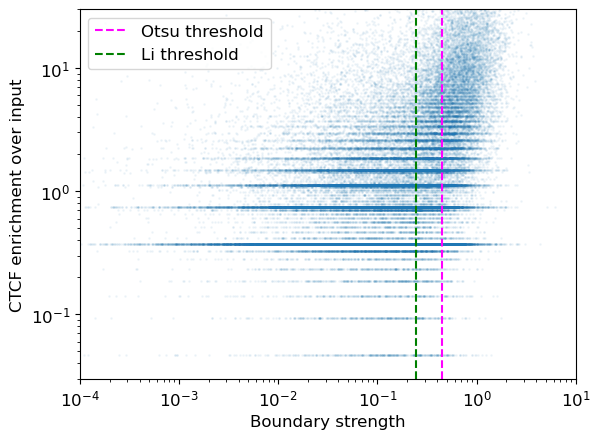

In [27]:
w=windows[0]
f, ax = plt.subplots()
ax.loglog(
    boundaries_2[f'boundary_strength_{w}'],
    ctcf_chip_signal_2,
    'o',
    markersize=1,
    alpha=0.05
);
ax.set(
    xlim=(1e-4,1e1),
    ylim=(3e-2,3e1),
    xlabel='Boundary strength',
    ylabel='CTCF enrichment over input')

ax.axvline(thresholds_otsu_2[w], ls='--', color='magenta', label='Otsu threshold')
ax.axvline(thresholds_li_2[w], ls='--', color='green', label='Li threshold')
ax.legend()

---

In [28]:
chosen_w = 50000  # 50 - 10 * 5 kb bins

In [29]:
# Apply Otsu/Li filters to select strong boundaries
# === CTRL ===
ctrl_bounds_otsu = insulation_table_2.query(f"is_boundary_{chosen_w}")[
    ["chrom","start","end",f"boundary_strength_{chosen_w}"]
].rename(columns={f"boundary_strength_{chosen_w}":"ctrl_strength"})
ctrl_bounds_otsu = ctrl_bounds_otsu[ctrl_bounds_otsu["ctrl_strength"] >= thresholds_otsu_2[chosen_w]]

ctrl_bounds_li = insulation_table_2.query(f"is_boundary_{chosen_w}")[
    ["chrom","start","end",f"boundary_strength_{chosen_w}"]
].rename(columns={f"boundary_strength_{chosen_w}":"ctrl_strength"})
ctrl_bounds_li = ctrl_bounds_li[ctrl_bounds_li["ctrl_strength"] >= thresholds_li_2[chosen_w]]

# === RBP1 ===
rbp1_bounds_otsu = insulation_table_1.query(f"is_boundary_{chosen_w}")[
    ["chrom","start","end",f"boundary_strength_{chosen_w}"]
].rename(columns={f"boundary_strength_{chosen_w}":"rbp1_strength"})
rbp1_bounds_otsu = rbp1_bounds_otsu[rbp1_bounds_otsu["rbp1_strength"] >= thresholds_otsu_1[chosen_w]]

rbp1_bounds_li = insulation_table_1.query(f"is_boundary_{chosen_w}")[
    ["chrom","start","end",f"boundary_strength_{chosen_w}"]
].rename(columns={f"boundary_strength_{chosen_w}":"rbp1_strength"})
rbp1_bounds_li = rbp1_bounds_li[rbp1_bounds_li["rbp1_strength"] >= thresholds_li_1[chosen_w]]

#ctrl_bounds_otsu

In [30]:
ctrl_bounds_otsu.to_csv("ctrl_boundaries_otsu.bed", sep="\t", header=False, index=False)
rbp1_bounds_otsu.to_csv("rbp1_boundaries_otsu.bed", sep="\t", header=False, index=False)

ctrl_bounds_li.to_csv("ctrl_boundaries_li.bed", sep="\t", header=False, index=False)
rbp1_bounds_li.to_csv("rbp1_boundaries_li.bed", sep="\t", header=False, index=False)

In [31]:
# Otsu
bounds_otsu = pd.read_csv("merged_ctrl_rbp1_otsu.clean.bed", sep="\t", header=None,
                          names=["chrom","start","end","ctrl_strength","rbp1_strength"])

# Convert safely
bounds_otsu["ctrl_strength"] = pd.to_numeric(bounds_otsu["ctrl_strength"], errors="coerce")
bounds_otsu["rbp1_strength"] = pd.to_numeric(bounds_otsu["rbp1_strength"], errors="coerce")

# Compute Δstrength
bounds_otsu["delta_strength"] = bounds_otsu["rbp1_strength"] - bounds_otsu["ctrl_strength"]
bounds_otsu.to_csv("all_boundaries_delta_otsu.tsv", sep="\t", index=False)


# Li
bounds_li = pd.read_csv("merged_ctrl_rbp1_li.clean.bed", sep="\t", header=None,
                        names=["chrom","start","end","ctrl_strength","rbp1_strength"])

bounds_li["ctrl_strength"] = pd.to_numeric(bounds_li["ctrl_strength"], errors="coerce")
bounds_li["rbp1_strength"] = pd.to_numeric(bounds_li["rbp1_strength"], errors="coerce")

bounds_li["delta_strength"] = bounds_li["rbp1_strength"] - bounds_li["ctrl_strength"]
bounds_li.to_csv("all_boundaries_delta_li.tsv", sep="\t", index=False)


# Quick summaries
print("Otsu Δstrength summary:\n", bounds_otsu["delta_strength"].describe())
print("Li Δstrength summary:\n", bounds_li["delta_strength"].describe())


Otsu Δstrength summary:
 count    8886.000000
mean       -0.010966
std         0.231221
min        -2.373692
25%        -0.107949
50%        -0.008778
75%         0.090406
max         2.226518
Name: delta_strength, dtype: float64
Li Δstrength summary:
 count    18096.000000
mean        -0.000403
std          0.208358
min         -2.373692
25%         -0.091118
50%         -0.000200
75%          0.093296
max          2.226518
Name: delta_strength, dtype: float64


In [32]:
weakened_otsu = bounds_otsu[bounds_otsu["delta_strength"] < 0]
weakened_li   = bounds_li[bounds_li["delta_strength"] < 0]

In [33]:
weakened_otsu[["chrom","start","end"]].to_csv("weakened_boundaries_otsu.bed",
                                              sep="\t", header=False, index=False)
weakened_li[["chrom","start","end"]].to_csv("weakened_boundaries_li.bed",
                                            sep="\t", header=False, index=False)

In [34]:
from pathlib import Path
from scipy.stats import fisher_exact

# Working directory
wd = Path("/usr/users/papantonis1/aman/rnaseq_data/")

def fisher_test(label, deg_file, bg_file, near_deg_file, near_bg_file):
    # Prepend working directory
    deg_file = wd / deg_file
    bg_file = wd / bg_file
    near_deg_file = wd / near_deg_file
    near_bg_file = wd / near_bg_file

    n_deg_total = sum(1 for _ in open(deg_file))
    n_bg_total  = sum(1 for _ in open(bg_file))
    n_deg_near  = sum(1 for _ in open(near_deg_file))
    n_bg_near   = sum(1 for _ in open(near_bg_file))

    table = [[n_deg_near, n_deg_total-n_deg_near],
             [n_bg_near, n_bg_total-n_bg_near]]
    odds, p = fisher_exact(table)
    print(f"{label}: {table}, OR={odds:.2f}, p={p:.2e}")


# Run tests
fisher_test("UP (Otsu)",
            "up_TSS_DEGs_gtfgencode.bed", "bg_up_TSS.bed",
            "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/up_near_weakened_otsu.tsv", "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/bg_up_near_weakened_otsu.tsv")

fisher_test("DOWN (Otsu)",
            "down_TSS_DEGs_gtfgencode.bed", "bg_down_TSS.bed",
            "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/down_near_weakened_otsu.tsv", "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/bg_down_near_weakened_otsu.tsv")

fisher_test("UP (Li)",
            "up_TSS_DEGs_gtfgencode.bed", "bg_up_TSS.bed",
            "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/up_near_weakened_li.tsv", "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/bg_up_near_weakened_li.tsv")

fisher_test("DOWN (Li)",
            "down_TSS_DEGs_gtfgencode.bed", "bg_down_TSS.bed",
            "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/down_near_weakened_li.tsv", "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/bg_down_near_weakened_li.tsv")


UP (Otsu): [[75, 147], [21, 201]], OR=4.88, p=4.19e-10
DOWN (Otsu): [[18, 64], [11, 71]], OR=1.82, p=2.19e-01
UP (Li): [[102, 120], [31, 191]], OR=5.24, p=1.46e-13
DOWN (Li): [[25, 57], [14, 68]], OR=2.13, p=6.58e-02


/tmp/ipykernel_659722/2828482916.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Group", y="%Near", palette=custom_palette, ax=ax)


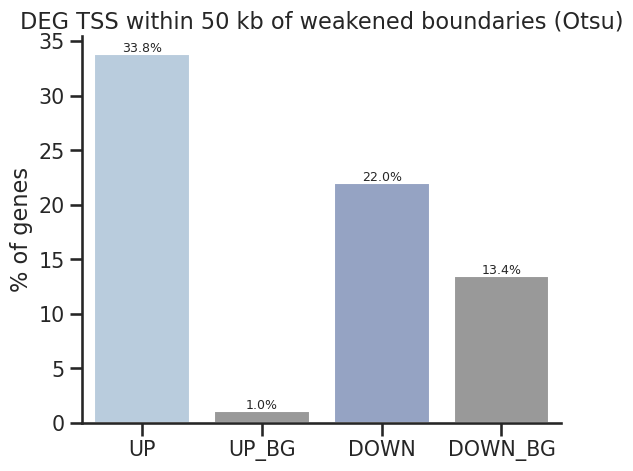

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# === Input counts from your Fisher tables ===
# Example for Otsu (swap in Li if you want that version)
counts = {
    "UP":      [75, 147],   # [near, not-near]
    "UP_BG":   [21, 2011],
    "DOWN":    [18, 64],
    "DOWN_BG": [11, 71],
}

# === Prepare dataframe ===
df = []
for label,(near,notnear) in counts.items():
    total = near+notnear
    pct   = 100*near/total
    df.append({"Group": label, "Near": near, "Total": total, "%Near": pct})
df = pd.DataFrame(df)

# === Plot ===
custom_palette = {
    "UP":"#b3cde3", "UP_BG":"#999999",
    "DOWN":"#8da0cb", "DOWN_BG":"#999999"
}

sns.set_theme(style="ticks", rc={"axes.spines.top": False, "axes.spines.right": False})
sns.set_context("talk", font_scale=0.9)

fig, ax = plt.subplots(figsize=(6,5))
sns.barplot(data=df, x="Group", y="%Near", palette=custom_palette, ax=ax)

ax.set_title("DEG TSS within 50 kb of weakened boundaries (Otsu)")
ax.set_xlabel("")
ax.set_ylabel("% of genes")

# Annotate values
for p in ax.patches:
    value = p.get_height()
    ax.annotate(f"{value:.1f}%",
                (p.get_x() + p.get_width() / 2., value),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("deg_boundary_proximity_barplot_otsu.png", dpi=200)
plt.show()


/tmp/ipykernel_659722/2366496464.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Group", y="%Near", palette=custom_palette, ax=ax)


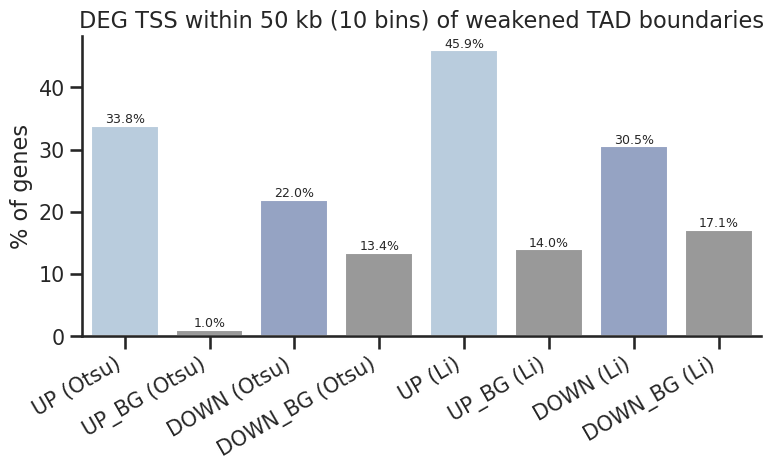

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === Input counts [near, not-near] ===
counts = {
    "UP (Otsu)":      [75, 147],
    "UP_BG (Otsu)":   [21, 2011],
    "DOWN (Otsu)":    [18, 64],
    "DOWN_BG (Otsu)": [11, 71],
    "UP (Li)":        [102, 120],
    "UP_BG (Li)":     [31, 191],
    "DOWN (Li)":      [25, 57],
    "DOWN_BG (Li)":   [14, 68],
}

# === Prepare dataframe ===
df = []
for label, (near, notnear) in counts.items():
    total = near + notnear
    pct = 100 * near / total
    df.append({"Group": label, "Near": near, "Total": total, "%Near": pct})
df = pd.DataFrame(df)

# === Plot ===
custom_palette = {
    "UP (Otsu)": "#b3cde3", "UP_BG (Otsu)": "#999999",
    "DOWN (Otsu)": "#8da0cb", "DOWN_BG (Otsu)": "#999999",
    "UP (Li)": "#b3cde3", "UP_BG (Li)": "#999999",
    "DOWN (Li)": "#8da0cb", "DOWN_BG (Li)": "#999999",
}

sns.set_theme(style="ticks", rc={"axes.spines.top": False, "axes.spines.right": False})
sns.set_context("talk", font_scale=0.9)

fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=df, x="Group", y="%Near", palette=custom_palette, ax=ax)

ax.set_title("DEG TSS within 50 kb (10 bins) of weakened TAD boundaries")
ax.set_xlabel("")
ax.set_ylabel("% of genes")

# Annotate values on bars
for p in ax.patches:
    value = p.get_height()
    ax.annotate(f"{value:.1f}%",
                (p.get_x() + p.get_width() / 2., value),
                ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=30, ha="right")  # rotate labels for readability
plt.tight_layout()
plt.savefig("deg_boundary_proximity_barplot_10bins.png", dpi=200)
plt.show()

In [37]:
### 5 bins shift

from pathlib import Path
from scipy.stats import fisher_exact

# Working directory
wd = Path("/usr/users/papantonis1/aman/rnaseq_data/")

def resolve_path(file):
    """Return Path object, keeping absolute paths untouched."""
    p = Path(file)
    return p if p.is_absolute() else wd / p

def fisher_test(label, deg_file, bg_file, near_deg_file, near_bg_file):
    deg_file = resolve_path(deg_file)
    bg_file = resolve_path(bg_file)
    near_deg_file = resolve_path(near_deg_file)
    near_bg_file = resolve_path(near_bg_file)

    n_deg_total = sum(1 for _ in open(deg_file))
    n_bg_total  = sum(1 for _ in open(bg_file))
    n_deg_near  = sum(1 for _ in open(near_deg_file))
    n_bg_near   = sum(1 for _ in open(near_bg_file))

    table = [[n_deg_near, n_deg_total-n_deg_near],
             [n_bg_near, n_bg_total-n_bg_near]]
    odds, p = fisher_exact(table)
    print(f"{label}: {table}, OR={odds:.2f}, p={p:.2e}")


# Run tests
fisher_test("UP (Otsu)",
            "up_TSS_DEGs_gtfgencode.bed", "bg_up_TSS.bed",
            "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/up_near_weakened_otsu.tsv",
            "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/bg_up_near_weakened_otsu.tsv")

fisher_test("DOWN (Otsu)",
            "down_TSS_DEGs_gtfgencode.bed", "bg_down_TSS.bed",
            "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/down_near_weakened_otsu.tsv",
            "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/bg_down_near_weakened_otsu.tsv")

fisher_test("UP (Li)",
            "up_TSS_DEGs_gtfgencode.bed", "bg_up_TSS.bed",
            "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/up_near_weakened_li.tsv",
            "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/bg_up_near_weakened_li.tsv")

fisher_test("DOWN (Li)",
            "down_TSS_DEGs_gtfgencode.bed", "bg_down_TSS.bed",
            "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/down_near_weakened_li.tsv",
            "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/bg_down_near_weakened_li.tsv")


UP (Otsu): [[75, 147], [21, 201]], OR=4.88, p=4.19e-10
DOWN (Otsu): [[18, 64], [11, 71]], OR=1.82, p=2.19e-01
UP (Li): [[102, 120], [31, 191]], OR=5.24, p=1.46e-13
DOWN (Li): [[25, 57], [14, 68]], OR=2.13, p=6.58e-02


/tmp/ipykernel_659722/2994963460.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Group", y="%Near", palette=custom_palette, ax=ax)


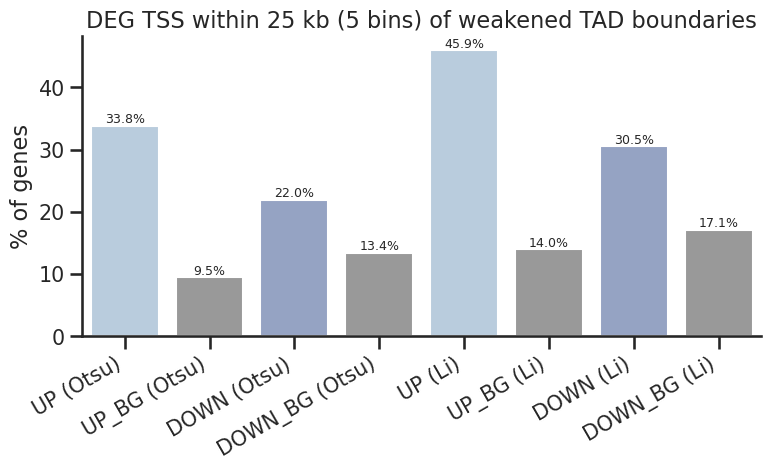

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# === Input counts [near, not-near] ===
counts = {
    "UP (Otsu)":      [75, 147],
    "UP_BG (Otsu)":   [21, 201],
    "DOWN (Otsu)":    [18, 64],
    "DOWN_BG (Otsu)": [11, 71],
    "UP (Li)":        [102, 120],
    "UP_BG (Li)":     [31, 191],
    "DOWN (Li)":      [25, 57],
    "DOWN_BG (Li)":   [14, 68],
}

# === Prepare dataframe ===
df = []
for label, (near, notnear) in counts.items():
    total = near + notnear
    pct = 100 * near / total
    df.append({"Group": label, "Near": near, "Total": total, "%Near": pct})
df = pd.DataFrame(df)

# === Plot ===
custom_palette = {
    "UP (Otsu)": "#b3cde3", "UP_BG (Otsu)": "#999999",
    "DOWN (Otsu)": "#8da0cb", "DOWN_BG (Otsu)": "#999999",
    "UP (Li)": "#b3cde3", "UP_BG (Li)": "#999999",
    "DOWN (Li)": "#8da0cb", "DOWN_BG (Li)": "#999999",
}

sns.set_theme(style="ticks", rc={"axes.spines.top": False, "axes.spines.right": False})
sns.set_context("talk", font_scale=0.9)

fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=df, x="Group", y="%Near", palette=custom_palette, ax=ax)

ax.set_title("DEG TSS within 25 kb (5 bins) of weakened TAD boundaries")
ax.set_xlabel("")
ax.set_ylabel("% of genes")

# Annotate percentages
for p in ax.patches:
    value = p.get_height()
    ax.annotate(f"{value:.1f}%",
                (p.get_x() + p.get_width() / 2., value),
                ha="center", va="bottom", fontsize=9)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("deg_boundary_proximity_barplot.png", dpi=200)
plt.show()

In [39]:
### 3 bin shift

### 5 bins shift

from pathlib import Path
from scipy.stats import fisher_exact

# Working directory
wd = Path("/usr/users/papantonis1/aman/rnaseq_data/")

def resolve_path(file):
    """Return Path object, keeping absolute paths untouched."""
    p = Path(file)
    return p if p.is_absolute() else wd / p

def fisher_test(label, deg_file, bg_file, near_deg_file, near_bg_file):
    deg_file = resolve_path(deg_file)
    bg_file = resolve_path(bg_file)
    near_deg_file = resolve_path(near_deg_file)
    near_bg_file = resolve_path(near_bg_file)

    n_deg_total = sum(1 for _ in open(deg_file))
    n_bg_total  = sum(1 for _ in open(bg_file))
    n_deg_near  = sum(1 for _ in open(near_deg_file))
    n_bg_near   = sum(1 for _ in open(near_bg_file))

    table = [[n_deg_near, n_deg_total-n_deg_near],
             [n_bg_near, n_bg_total-n_bg_near]]
    odds, p = fisher_exact(table)
    print(f"{label}: {table}, OR={odds:.2f}, p={p:.2e}")


# Run tests
fisher_test("UP (Otsu, 15 kb)",
            "up_TSS_DEGs_gtfgencode.bed", "bg_up_TSS.bed",
            "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/up_near_weakened_otsu_15kb.tsv", "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/bg_up_near_weakened_otsu_15kb.tsv")

fisher_test("DOWN (Otsu, 15 kb)",
            "down_TSS_DEGs_gtfgencode.bed", "bg_down_TSS.bed",
            "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/down_near_weakened_otsu_15kb.tsv", "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/bg_down_near_weakened_otsu_15kb.tsv")

fisher_test("UP (Li, 15 kb)",
            "up_TSS_DEGs_gtfgencode.bed", "bg_up_TSS.bed",
            "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/up_near_weakened_li_15kb.tsv", "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/bg_up_near_weakened_li_15kb.tsv")

fisher_test("DOWN (Li, 15 kb)",
            "down_TSS_DEGs_gtfgencode.bed", "bg_down_TSS.bed",
            "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/down_near_weakened_li_15kb.tsv", "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/bg_down_near_weakened_li_15kb.tsv")



UP (Otsu, 15 kb): [[31, 191], [11, 211]], OR=3.11, p=1.77e-03
DOWN (Otsu, 15 kb): [[8, 74], [4, 78]], OR=2.11, p=3.69e-01
UP (Li, 15 kb): [[59, 163], [15, 207]], OR=5.00, p=1.91e-08
DOWN (Li, 15 kb): [[13, 69], [6, 76]], OR=2.39, p=1.42e-01


/tmp/ipykernel_659722/1516269021.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Group", y="%Near", palette=custom_palette, ax=ax)


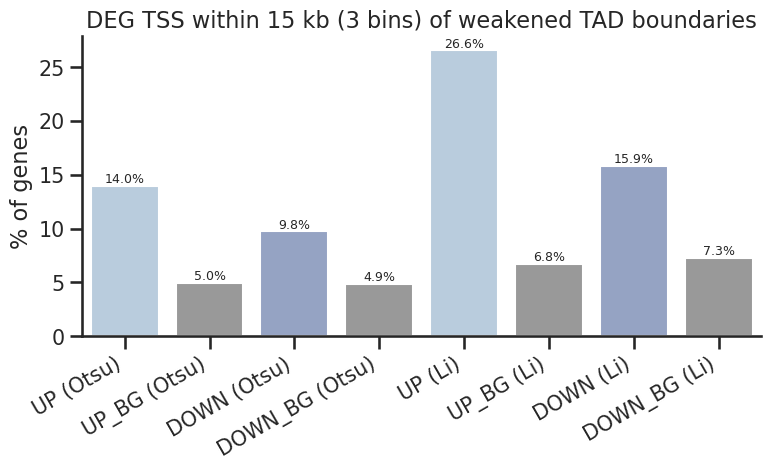

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === Input counts [near, not-near] for 15 kb ===
counts = {
    "UP (Otsu)":      [31, 191],
    "UP_BG (Otsu)":   [11, 211],
    "DOWN (Otsu)":    [8, 74],
    "DOWN_BG (Otsu)": [4, 78],
    "UP (Li)":        [59, 163],
    "UP_BG (Li)":     [15, 207],
    "DOWN (Li)":      [13, 69],
    "DOWN_BG (Li)":   [6, 76],
}

# === Prepare dataframe ===
df = []
for label, (near, notnear) in counts.items():
    total = near + notnear
    pct = 100 * near / total
    df.append({"Group": label, "Near": near, "Total": total, "%Near": pct})
df = pd.DataFrame(df)

# === Plot ===
custom_palette = {
    "UP (Otsu)": "#b3cde3", "UP_BG (Otsu)": "#999999",
    "DOWN (Otsu)": "#8da0cb", "DOWN_BG (Otsu)": "#999999",
    "UP (Li)": "#b3cde3", "UP_BG (Li)": "#999999",
    "DOWN (Li)": "#8da0cb", "DOWN_BG (Li)": "#999999",
}

sns.set_theme(style="ticks", rc={"axes.spines.top": False, "axes.spines.right": False})
sns.set_context("talk", font_scale=0.9)

fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=df, x="Group", y="%Near", palette=custom_palette, ax=ax)

ax.set_title("DEG TSS within 15 kb (3 bins) of weakened TAD boundaries")
ax.set_xlabel("")
ax.set_ylabel("% of genes")

# Annotate values on bars
for p in ax.patches:
    value = p.get_height()
    ax.annotate(f"{value:.1f}%",
                (p.get_x() + p.get_width() / 2., value),
                ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=30, ha="right")  # rotate labels
plt.tight_layout()
plt.savefig("deg_boundary_proximity_barplot_15kb.png", dpi=200)
plt.show()

In [41]:
# exact

### 3 bin shift

### 5 bins shift

from pathlib import Path
from scipy.stats import fisher_exact

# Working directory
wd = Path("/usr/users/papantonis1/aman/rnaseq_data/")

def resolve_path(file):
    """Return Path object, keeping absolute paths untouched."""
    p = Path(file)
    return p if p.is_absolute() else wd / p

def fisher_test(label, deg_file, bg_file, near_deg_file, near_bg_file):
    deg_file = resolve_path(deg_file)
    bg_file = resolve_path(bg_file)
    near_deg_file = resolve_path(near_deg_file)
    near_bg_file = resolve_path(near_bg_file)

    n_deg_total = sum(1 for _ in open(deg_file))
    n_bg_total  = sum(1 for _ in open(bg_file))
    n_deg_near  = sum(1 for _ in open(near_deg_file))
    n_bg_near   = sum(1 for _ in open(near_bg_file))

    table = [[n_deg_near, n_deg_total-n_deg_near],
             [n_bg_near, n_bg_total-n_bg_near]]
    odds, p = fisher_exact(table)
    print(f"{label}: {table}, OR={odds:.2f}, p={p:.2e}")


# Run tests
fisher_test("UP (Otsu, 0 bin)",
            "up_TSS_DEGs_gtfgencode.bed", "bg_up_TSS.bed",
            "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/up_near_weakened_otsu_0bin.tsv", "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/bg_up_near_weakened_otsu_0bin.tsv")

fisher_test("DOWN (Otsu, 0 bin)",
            "down_TSS_DEGs_gtfgencode.bed", "bg_down_TSS.bed",
            "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/down_near_weakened_otsu_0bin.tsv", "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/bg_down_near_weakened_otsu_0bin.tsv")

fisher_test("UP (Li, 0 bin)",
            "up_TSS_DEGs_gtfgencode.bed", "bg_up_TSS.bed",
            "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/up_near_weakened_li_0bin.tsv", "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/bg_up_near_weakened_li_0bin.tsv")

fisher_test("DOWN (Li, 0 bin)",
            "down_TSS_DEGs_gtfgencode.bed", "bg_down_TSS.bed",
            "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/down_near_weakened_li_0bin.tsv", "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/bg_down_near_weakened_li_0bin.tsv")




UP (Otsu, 0 bin): [[13, 209], [7, 215]], OR=1.91, p=2.52e-01
DOWN (Otsu, 0 bin): [[4, 78], [0, 82]], OR=inf, p=1.20e-01
UP (Li, 0 bin): [[26, 196], [11, 211]], OR=2.54, p=1.52e-02
DOWN (Li, 0 bin): [[5, 77], [3, 79]], OR=1.71, p=7.20e-01


In [42]:
#Upregulated genes consistently localize near weakened TAD boundaries across multiple window sizes (15 kb, 25 kb, 50 kb), and enrichment is detectable even under the strictest definition (exact overlap).

/tmp/ipykernel_659722/1923343046.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Group", y="%Near", palette=custom_palette, ax=ax)


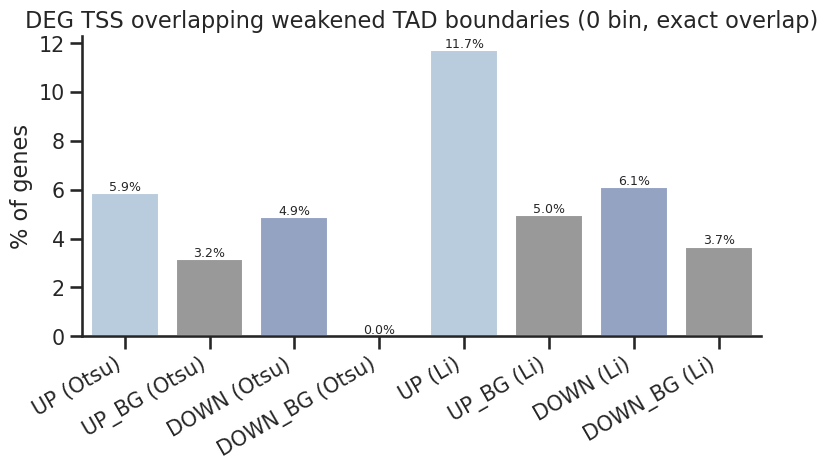

In [43]:
# === Input counts [near, not-near] for 0 bin ===
counts = {
    "UP (Otsu)":      [13, 209],
    "UP_BG (Otsu)":   [7, 215],
    "DOWN (Otsu)":    [4, 78],
    "DOWN_BG (Otsu)": [0, 82],
    "UP (Li)":        [26, 196],
    "UP_BG (Li)":     [11, 211],
    "DOWN (Li)":      [5, 77],
    "DOWN_BG (Li)":   [3, 79],
}

# === Prepare dataframe ===
df = []
for label, (near, notnear) in counts.items():
    total = near + notnear
    pct = 100 * near / total if total > 0 else 0
    df.append({"Group": label, "Near": near, "Total": total, "%Near": pct})
df = pd.DataFrame(df)

# === Plot ===
custom_palette = {
    "UP (Otsu)": "#b3cde3", "UP_BG (Otsu)": "#999999",
    "DOWN (Otsu)": "#8da0cb", "DOWN_BG (Otsu)": "#999999",
    "UP (Li)": "#b3cde3", "UP_BG (Li)": "#999999",
    "DOWN (Li)": "#8da0cb", "DOWN_BG (Li)": "#999999",
}

sns.set_theme(style="ticks", rc={"axes.spines.top": False, "axes.spines.right": False})
sns.set_context("talk", font_scale=0.9)

fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=df, x="Group", y="%Near", palette=custom_palette, ax=ax)

ax.set_title("DEG TSS overlapping weakened TAD boundaries (0 bin, exact overlap)")
ax.set_xlabel("")
ax.set_ylabel("% of genes")

# Annotate values
for p in ax.patches:
    value = p.get_height()
    ax.annotate(f"{value:.1f}%",
                (p.get_x() + p.get_width() / 2., value),
                ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=30, ha="right")  # avoid overlapping labels
plt.tight_layout()
plt.savefig("deg_boundary_proximity_barplot_0bin.png", dpi=200)
plt.show()


In [44]:
#Δinsulation table at 50 kb

w = 50000
col = f"log2_insulation_score_{w}"

d1 = insulation_table_1[["chrom","start","end", col]].rename(columns={col:"insul_cpi"})
d2 = insulation_table_2[["chrom","start","end", col]].rename(columns={col:"insul_ctrl"})

delta = d1.merge(d2, on=["chrom","start","end"], how="inner")
delta["delta_insul"] = delta["insul_cpi"] - delta["insul_ctrl"]   # CPI − CTRL
delta = delta[["chrom","start","end","delta_insul"]]
delta.head()

,chrom,start,end,delta_insul
0,chr1,0,5000,NaN
1,chr1,5000,10000,NaN
2,chr1,10000,15000,NaN
3,chr1,15000,20000,NaN
4,chr1,20000,25000,NaN


In [45]:
delta.tail()

,chrom,start,end,delta_insul
617664,chrY,57225000,57227415,NaN
617665,chrM,0,5000,0.144766
617666,chrM,5000,10000,-0.074117
617667,chrM,10000,15000,-0.074117
617668,chrM,15000,16569,0.066998


In [46]:
up_tss=pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/up_TSS_DEGs_gtfgencode.bed", sep="\t", header=None)
down_tss=pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/down_TSS_DEGs_gtfgencode.bed", sep="\t", header=None)
all_deg_tss = pd.concat([up_tss, down_tss], ignore_index=True)
all_deg_tss.columns = ["chrom", "start", "end", "gene_id", "score", "strand"]
all_deg_tss.head()

,chrom,start,end,gene_id,score,strand
0,chr1,9823983,9823984,ENSG00000171603,0,-
1,chr1,11934204,11934205,ENSG00000083444,0,+
2,chr1,21345571,21345572,ENSG00000117298,0,-
3,chr1,22710838,22710839,ENSG00000133216,0,+
4,chr1,27166980,27166981,ENSG00000090020,0,-


In [47]:
# === CONFIG ===
UP_TSS_BED   = "/usr/users/papantonis1/aman/rnaseq_data/up_TSS_DEGs_gtfgencode.bed"
DOWN_TSS_BED = "/usr/users/papantonis1/aman/rnaseq_data/down_TSS_DEGs_gtfgencode.bed"
WINDOW_BP    = 50_000   # ±50 kb

import numpy as np
import pandas as pd
import bioframe as bf

# --- Load & unify TSS BED6 ---
up  = pd.read_csv(UP_TSS_BED,   sep="\t", header=None)
down= pd.read_csv(DOWN_TSS_BED, sep="\t", header=None)
tss = pd.concat([up, down], ignore_index=True)
tss.columns = ["chrom","start","end","gene_id","score","strand"]
tss["chrom"] = tss["chrom"].astype(str)
tss["start"] = tss["start"].astype(int)
tss["end"]   = tss["end"].astype(int)

# --- Chromsizes from cooler object `clr_1` ---
chromsizes = dict(zip(clr_1.chromnames, clr_1.chromsizes))

# --- Window around each TSS ---
tss_win = tss[["chrom","start","end","gene_id"]].copy()
tss_win["win_start"] = (tss_win["start"] - WINDOW_BP).clip(lower=0)
tss_win["win_end"]   =  tss_win["end"] + WINDOW_BP
tss_win["win_end"]   = tss_win[["chrom","win_end"]].apply(
    lambda r: min(int(r["win_end"]), int(chromsizes[r["chrom"]])), axis=1
)

# --- Prepare delta table (must already exist as `delta`) ---
# Detect coordinate/value column names robustly
def _detect(colnames, candidates):
    for c in candidates:
        if c in colnames:
            return c
    return None

col_chrom = _detect(delta.columns, ["chrom","chr","chromosome"])
col_start = _detect(delta.columns, ["start","chromStart","bin_start","st"])
col_end   = _detect(delta.columns, ["end","chromEnd","bin_end","en"])
col_val   = _detect(delta.columns, ["delta_insul","delta","delta_insulation",
                                    "delta_insulation_score","value","score"])

missing = {k:v for k,v in {"chrom":col_chrom,"start":col_start,"end":col_end,"value":col_val}.items() if v is None}
if missing:
    raise ValueError(f"delta missing required columns (any of the accepted aliases): {missing}; "
                     f"available: {list(delta.columns)}")

delta2 = (delta.rename(columns={col_chrom:"chrom", col_start:"start", col_end:"end", col_val:"score"})
               [["chrom","start","end","score"]]
               .copy())
delta2["chrom"] = delta2["chrom"].astype(str)
delta2["start"] = delta2["start"].astype(int)
delta2["end"]   = delta2["end"].astype(int)
delta2["score"] = delta2["score"].astype(float)

# --- Overlap (explicit columns) ---
ov = bf.overlap(
    tss_win[["chrom","win_start","win_end","gene_id"]],
    delta2,
    cols1=("chrom","win_start","win_end"),
    cols2=("chrom","start","end"),
    suffixes=("_tss",""),
    return_input=True
)

# --- Overlap length and weighted mean per gene ---
ov["overlap_len"] = (
    np.minimum(ov["win_end_tss"], ov["end"]) - np.maximum(ov["win_start_tss"], ov["start"])
).clip(lower=0)
ov = ov.loc[ov["overlap_len"] > 0].copy()

agg = (ov.groupby("gene_id_tss")
         .apply(lambda g: np.average(g["score"], weights=g["overlap_len"]))
         .reset_index(name=f"deltaInsul_pm{WINDOW_BP//1000}kb"))

# Optional join back to TSS
tss_with_delta = (tss.merge(agg, left_on="gene_id", right_on="gene_id_tss", how="left")
                     .drop(columns=["gene_id_tss"]))

print(agg.head())


       gene_id_tss  deltaInsul_pm50kb
0  ENSG00000005339          -0.052473
1  ENSG00000010292          -0.136786
2  ENSG00000011347           0.015913
3  ENSG00000013288           0.064838
4  ENSG00000026036                NaN


/tmp/ipykernel_659722/1879123327.py:74: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["score"], weights=g["overlap_len"]))


In [48]:
# load up/down tables (with log2FC)
up_genes = pd.read_csv(
    "/usr/users/papantonis1/aman/rnaseq_data/upregulated_genes_deseq.txt",
    sep="\t"
)
down_genes = pd.read_csv(
    "/usr/users/papantonis1/aman/rnaseq_data/downregulated_genes_deseq.txt",
    sep="\t"
)

# add a status column before merging
up_genes["status"] = "UP"
down_genes["status"] = "DOWN"

# combine them
deg = pd.concat([up_genes, down_genes], ignore_index=True)

# align naming with agg
agg = agg.rename(columns={"gene_id_tss":"ensembl_id"})

# merge to get log2FC + status
agg_fc = agg.merge(deg[["ensembl_id","log2FC","status"]], on="ensembl_id", how="inner")

print(agg_fc.head())

        ensembl_id  deltaInsul_pm50kb    log2FC status
0  ENSG00000005339          -0.052473  0.653104     UP
1  ENSG00000010292          -0.136786  0.711214     UP
2  ENSG00000011347           0.015913  0.696552     UP
3  ENSG00000013288           0.064838  0.703644     UP
4  ENSG00000026036                NaN -0.957709   DOWN


status
UP      211
DOWN     50
Name: count, dtype: int64


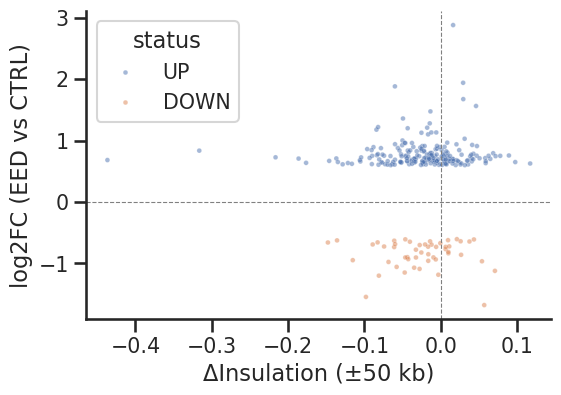

In [58]:
# merge
agg_fc = agg.merge(deg, on="ensembl_id", how="inner")

# keep DEG status from 'deg' (status_y), drop the other
agg_fc = (agg_fc
          .rename(columns={"status_y": "status"})
          .drop(columns=[c for c in ["status_x"] if c in agg_fc.columns]))

# ensure numeric + drop NA
agg_fc["deltaInsul_pm50kb"] = pd.to_numeric(agg_fc["deltaInsul_pm50kb"], errors="coerce")
agg_fc["log2FC"] = pd.to_numeric(agg_fc["log2FC"], errors="coerce")
plot_df = agg_fc.dropna(subset=["deltaInsul_pm50kb","log2FC","status"])

# check
print(plot_df["status"].value_counts())

# plot
import seaborn as sns, matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.scatterplot(data=plot_df, x="deltaInsul_pm50kb", y="log2FC",
                hue="status", alpha=0.5, s=12)
plt.axhline(0, color="grey", ls="--", lw=0.8)
plt.axvline(0, color="grey", ls="--", lw=0.8)
plt.xlabel("ΔInsulation (±50 kb)")
plt.ylabel("log2FC (EED vs CTRL)")
plt.show()

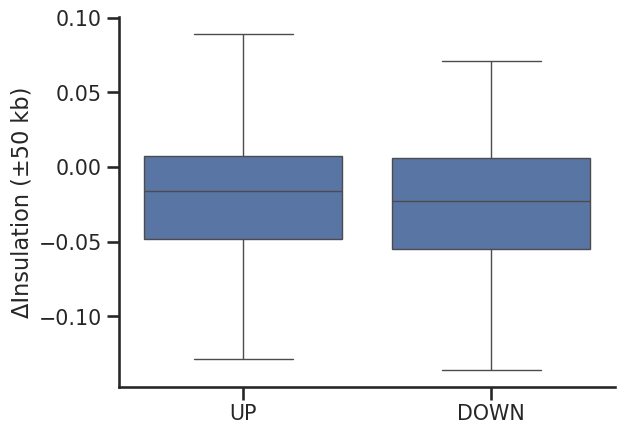

In [50]:
sns.boxplot(data=plot_df, x="status", y="deltaInsul_pm50kb", showfliers=False)
plt.ylabel("ΔInsulation (±50 kb)"); plt.xlabel("")
plt.show()


In [51]:
summary = (agg_fc
           .groupby("status")["deltaInsul_pm50kb"]
           .describe(percentiles=[0.25,0.5,0.75]))
print(summary[["mean","std","50%","25%","75%"]])

            mean       std       50%       25%      75%
status                                                 
DOWN   -0.026250  0.047524 -0.022990 -0.055174  0.00638
UP     -0.024092  0.060689 -0.015982 -0.048318  0.00732


In [52]:
agg

,ensembl_id,deltaInsul_pm50kb
0,ENSG00000005339,-0.052473
1,ENSG00000010292,-0.136786
2,ENSG00000011347,0.015913
3,ENSG00000013288,0.064838
4,ENSG00000026036,NaN
...,...,...
299,ENSG00000290076,-0.020528
300,ENSG00000290548,NaN
301,ENSG00000291100,NaN
302,ENSG00000291117,-0.147836


In [53]:
#### with nonDEG

/tmp/ipykernel_659722/2680974276.py:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g["score"], weights=g["overlap_len"]))


ΔInsulation table: (78686, 2)
Merged: status
nonDE    78382
UP         222
DOWN        82
Name: count, dtype: int64


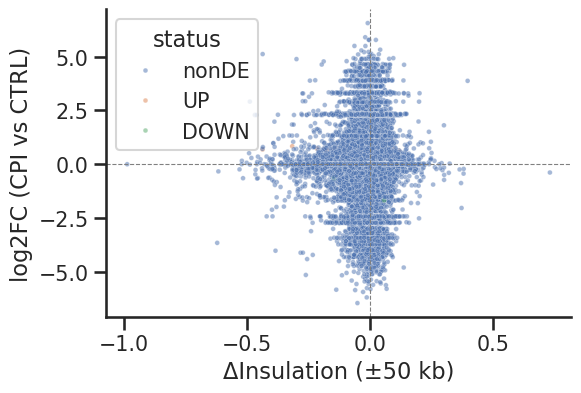

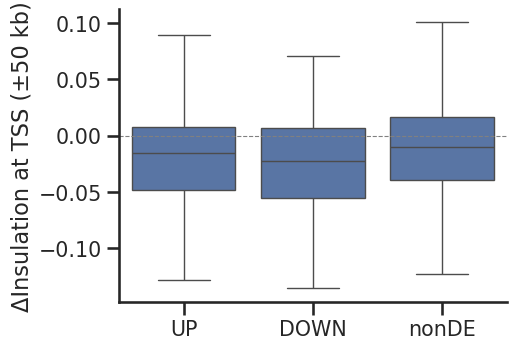

In [54]:
# === CONFIG ===
TSS_BED   = "/usr/users/papantonis1/aman/rnaseq_data/all_genes_TSS_gtfgencode.bed"
DE_FILE   = "/usr/users/papantonis1/aman/rnaseq_data/deseq_results_full_cpionly_3sep.tsv"
WINDOW_BP = 50_000   # ±50 kb

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import bioframe as bf

# --- 1) Load ALL TSS BED6 ---
tss = pd.read_csv(TSS_BED, sep="\t", header=None,
                  names=["chrom","start","end","ensembl_id","score","strand"])
tss["chrom"] = tss["chrom"].astype(str)
tss["start"] = tss["start"].astype(int)
tss["end"]   = tss["end"].astype(int)

# --- 2) Chromsizes from cooler object ---
chromsizes = dict(zip(clr_1.chromnames, clr_1.chromsizes))
tss = tss[tss["chrom"].isin(chromsizes.keys())].copy()

# --- 3) Window around each TSS ---
tss_win = tss[["chrom","start","end","ensembl_id"]].copy()
tss_win["win_start"] = (tss_win["start"] - WINDOW_BP).clip(lower=0)
tss_win["win_end"]   = np.minimum(tss_win["end"] + WINDOW_BP,
                                  tss_win["chrom"].map(chromsizes).astype(int))

# --- 4) Prepare delta table (must already exist as `delta`) ---
def _detect(colnames, candidates):
    for c in candidates:
        if c in colnames:
            return c
    return None

col_chrom = _detect(delta.columns, ["chrom","chr","chromosome"])
col_start = _detect(delta.columns, ["start","chromStart","bin_start","st"])
col_end   = _detect(delta.columns, ["end","chromEnd","bin_end","en"])
col_val   = _detect(delta.columns, ["delta_insul","delta","delta_insulation",
                                    "delta_insulation_score","value","score"])

delta2 = (delta.rename(columns={col_chrom:"chrom",
                                col_start:"start",
                                col_end:"end",
                                col_val:"score"})
               [["chrom","start","end","score"]]
               .copy())
delta2["chrom"] = delta2["chrom"].astype(str)
delta2["start"] = delta2["start"].astype(int)
delta2["end"]   = delta2["end"].astype(int)
delta2["score"] = delta2["score"].astype(float)

# --- 5) Overlap (explicit columns) ---
ov = bf.overlap(
    tss_win[["chrom","win_start","win_end","ensembl_id"]],
    delta2,
    cols1=("chrom","win_start","win_end"),
    cols2=("chrom","start","end"),
    suffixes=("_tss",""),
    return_input=True
)

# --- 6) Overlap length and weighted mean per gene ---
ov["overlap_len"] = (
    np.minimum(ov["win_end_tss"], ov["end"]) -
    np.maximum(ov["win_start_tss"], ov["start"])
).clip(lower=0)
ov = ov.loc[ov["overlap_len"] > 0].copy()

agg = (ov.groupby("ensembl_id_tss")
         .apply(lambda g: np.average(g["score"], weights=g["overlap_len"]))
         .reset_index(name=f"deltaInsul_pm{WINDOW_BP//1000}kb")
         .rename(columns={"ensembl_id_tss":"ensembl_id"}))

print("ΔInsulation table:", agg.shape)

# --- 7) Load DESeq2 full results and assign UP/DOWN/nonDE ---
de_full = pd.read_csv(DE_FILE, sep="\t").rename(
    columns={"gene_id":"ensembl_id","log2FoldChange":"log2FC"}
)

fc_thresh = 0.6
padj_thresh = 0.1

de_full["status"] = "nonDE"
de_full.loc[(de_full["padj"]<padj_thresh) & (de_full["log2FC"]>fc_thresh), "status"] = "UP"
de_full.loc[(de_full["padj"]<padj_thresh) & (de_full["log2FC"]<-fc_thresh), "status"] = "DOWN"

# --- 8) Merge Δinsulation with DE info ---
agg_all = agg.merge(de_full[["ensembl_id","log2FC","padj","status"]],
                    on="ensembl_id", how="inner")
print("Merged:", agg_all["status"].value_counts())

# --- 9) Plot: scatter ΔInsulation vs log2FC ---
plot_df = agg_all.dropna(subset=[f"deltaInsul_pm{WINDOW_BP//1000}kb","log2FC","status"])
plt.figure(figsize=(6,4))
sns.scatterplot(data=plot_df,
                x=f"deltaInsul_pm{WINDOW_BP//1000}kb", y="log2FC",
                hue="status", alpha=0.5, s=12)
plt.axhline(0, color="grey", ls="--", lw=0.8)
plt.axvline(0, color="grey", ls="--", lw=0.8)
plt.xlabel(f"ΔInsulation (±{WINDOW_BP//1000} kb)")
plt.ylabel("log2FC (CPI vs CTRL)")
plt.show()

# --- 10) Boxplot with baseline ---
plt.figure(figsize=(5,3.8))
sns.boxplot(data=plot_df, x="status", y=f"deltaInsul_pm{WINDOW_BP//1000}kb",
            order=["UP","DOWN","nonDE"], showfliers=False)
plt.axhline(0, color="grey", ls="--", lw=0.8)
plt.ylabel(f"ΔInsulation at TSS (±{WINDOW_BP//1000} kb)")
plt.xlabel("")
plt.show()


In [55]:
summary = (
    agg_all
    .groupby("status")[f"deltaInsul_pm{WINDOW_BP//1000}kb"]
    .describe(percentiles=[0.25, 0.5, 0.75])
)

print(summary[["mean", "std", "50%", "25%", "75%"]])


            mean       std       50%       25%       75%
status                                                  
DOWN   -0.026250  0.047524 -0.022990 -0.055174  0.006380
UP     -0.024092  0.060689 -0.015982 -0.048318  0.007320
nonDE  -0.011429  0.054315 -0.008328 -0.037567  0.019495


In [56]:
from scipy.stats import mannwhitneyu

# Extract distributions
up_vals   = agg_all.loc[agg_all["status"]=="UP", f"deltaInsul_pm{WINDOW_BP//1000}kb"].dropna()
down_vals = agg_all.loc[agg_all["status"]=="DOWN", f"deltaInsul_pm{WINDOW_BP//1000}kb"].dropna()
nonde_vals= agg_all.loc[agg_all["status"]=="nonDE", f"deltaInsul_pm{WINDOW_BP//1000}kb"].dropna()

# Mann–Whitney tests
for label, vals in [("UP vs nonDE", up_vals), ("DOWN vs nonDE", down_vals)]:
    stat, p = mannwhitneyu(vals, nonde_vals, alternative="two-sided")
    print(f"{label}: U={stat:.1f}, p={p:.2e}, n1={len(vals)}, n2={len(nonde_vals)}")

UP vs nonDE: U=6487506.0, p=1.35e-03, n1=211, n2=70486
DOWN vs nonDE: U=1422421.0, p=1.83e-02, n1=50, n2=70486


In [57]:
# Mann–Whitney U test results:
# - U: the test statistic (based on rank sums).
#       It measures how often values in group A are smaller/larger than values in group B.
# - p: the p-value (probability that the two groups come from the same distribution).
#       A small p (e.g. <0.05) means the distributions are significantly different.
# - n1: sample size of the first group (here, UP or DOWN genes).
# - n2: sample size of the second group (here, nonDE genes).
#
# In our results:
# - UP vs nonDE: p ≈ 1e-03 → highly significant difference.
# - DOWN vs nonDE: p ≈ 1.8e-02 → significant difference, but weaker.
#
# Interpretation: both UP and DOWN DEGs tend to have more negative Δinsulation values
# (weaker insulation around TSS) compared to nonDE genes.
# The effect is modest in size but statistically reliable.